# Recovery time distributions used in grp-SIS experiments

This notebook visualizes the **recovery waiting-time distributions** used in the NetLogo grp-SIS model and BehaviorSpace threshold experiments.

You can use these figures (and short accompanying text) both in the **proposal background** and in the **report introduction** to explain how non-Markovian recovery is modelled (following Tang et al., 2025).


In [1]:
from __future__ import annotations

import sys
from pathlib import Path
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        for name in ("netlogo", "NetLogo"):
            if (p / name / "virus_simulation.nlogox").is_file():
                return p
    raise FileNotFoundError(
        "Could not find netlogo/virus_simulation.nlogox. Open the repo root in Cursor (File → Open Folder)."
    )


ROOT = _project_root()
sys.path.insert(0, str(ROOT))

NETLOGO_DIR = next(
    ROOT / name
    for name in ("netlogo", "NetLogo")
    if (ROOT / name / "virus_simulation.nlogox").is_file()
)
BS_XML = NETLOGO_DIR / "behaviorspace_experiments.xml"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
ROOT

WindowsPath('C:/Dossiers/Master AI/Research Methods for AI (IM1312)/RMAI Research Project')

In [2]:
def load_bs_constants(experiment_name: str) -> dict[str, float]:
    """Parse BehaviorSpace XML to get the constant parameter values for an experiment.

    This keeps the plots in sync with the NetLogo experiments used for the paper.
    Only scalar constants are returned (no steppedValueSet ranges).
    """

    tree = ET.parse(BS_XML)
    root = tree.getroot()
    for expt in root.findall("experiment"):
        if expt.get("name") != experiment_name:
            continue
        consts = {}
        const_block = expt.find("constants")
        if const_block is None:
            return consts
        for vs in const_block.findall("enumeratedValueSet"):
            var = vs.get("variable")
            # Ignore string-valued choosers like network-type etc.
            if not vs.findall("value"):
                continue
            # Take the first value in the set; all our experiments use singletons here.
            raw = vs.findall("value")[0].get("value")
            if raw is None:
                continue
            try:
                consts[var] = float(raw)
            except ValueError:
                # Non-numeric (e.g. chooser strings) are skipped.
                continue
        return consts
    raise KeyError(f"Experiment {experiment_name!r} not found in {BS_XML}")


expo_params = load_bs_constants("02-threshold-exponential")
pl_params = load_bs_constants("03-threshold-power-law-Tang")
ln_params = load_bs_constants("04-threshold-lognormal-Tang")

expo_params, pl_params, ln_params

({'expt-seed': 1001.0,
  'num-nodes': 200.0,
  'avg-degree': 6.0,
  'rewiring-prob': 0.07,
  'initial-infected': 5.0,
  'recovery-mean': 5.0},
 {'expt-seed': 1001.0,
  'num-nodes': 200.0,
  'avg-degree': 6.0,
  'rewiring-prob': 0.07,
  'initial-infected': 5.0,
  'recovery-mean': 5.0,
  'power-law-lambda': 4.24},
 {'expt-seed': 1001.0,
  'num-nodes': 200.0,
  'avg-degree': 6.0,
  'rewiring-prob': 0.07,
  'initial-infected': 5.0,
  'recovery-mean': 5.0,
  'lognormal-sigma': 1.0})

In [3]:
rng = np.random.default_rng(202503)


def sample_recovery_times(
    distribution: str,
    n: int,
    *,
    recovery_mean: float,
    power_law_lambda: float | None = None,
    lognormal_sigma: float | None = None,
) -> np.ndarray:
    """Python analogue of NetLogo `draw-recovery-time` for the main regimes.

    We match the parameterisation used in `virus_simulation.nlogox`:
    - exponential: mean = recovery_mean
    - lognormal (Tang): E[W] = recovery_mean, sigma = lognormal_sigma
    - power law (Tang): shifted Pareto with slope power_law_lambda and E[W] = recovery_mean
    """

    distribution = distribution.lower()
    if n <= 0:
        return np.empty(0, dtype=float)

    if distribution == "deterministic":
        w = np.full(n, recovery_mean, dtype=float)
    elif distribution == "exponential":
        # Classical Markovian SIS with mean waiting time recovery_mean.
        w = rng.exponential(scale=recovery_mean, size=n)
    elif distribution.startswith("lognormal"):
        if lognormal_sigma is None:
            raise ValueError("lognormal_sigma must be provided for lognormal distribution")
        sig = max(1e-6, float(lognormal_sigma))
        mu = np.log(recovery_mean) - (sig**2) / 2.0
        w = rng.lognormal(mean=mu, sigma=sig, size=n)
    elif distribution.startswith("power law"):
        if power_law_lambda is None:
            raise ValueError("power_law_lambda must be provided for power law distribution")
        lam = max(2.01, float(power_law_lambda))
        t0 = recovery_mean * (lam - 2.0) / (lam - 1.0)
        v = rng.random(size=n)
        w = t0 * np.power(np.clip(v, 1e-12, 1.0), 1.0 / (1.0 - lam))
    else:
        raise ValueError(f"Unsupported distribution: {distribution!r}")

    # NetLogo rounds to integer ticks and enforces a minimum of 1 tick.
    w_ticks = np.clip(np.rint(w), 1.0, None)
    return w_ticks


N_SAMPLES = 200_000

expo_samples = sample_recovery_times(
    "exponential",
    N_SAMPLES,
    recovery_mean=expo_params["recovery-mean"],
)
powerlaw_samples = sample_recovery_times(
    "power law (Tang)",
    N_SAMPLES,
    recovery_mean=pl_params["recovery-mean"],
    power_law_lambda=pl_params["power-law-lambda"],
)
lognormal_samples = sample_recovery_times(
    "lognormal (Tang)",
    N_SAMPLES,
    recovery_mean=ln_params["recovery-mean"],
    lognormal_sigma=ln_params["lognormal-sigma"],
)

expo_samples.mean(), powerlaw_samples.mean(), lognormal_samples.mean()

(np.float64(5.080675), np.float64(5.045975), np.float64(5.038155))

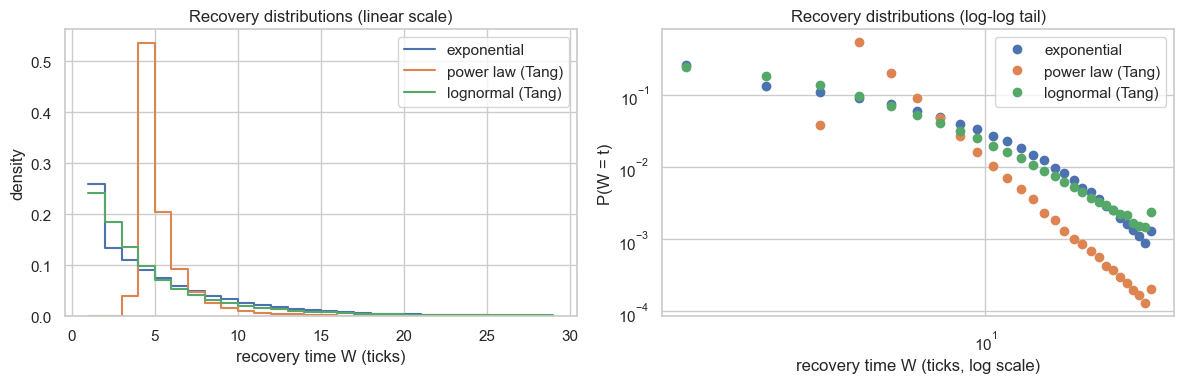

In [4]:
def plot_recovery_histograms(save: bool = True) -> None:
    """Side-by-side comparison of the three recovery regimes.

    Panel (a): linear scale to highlight the bulk of the mass.
    Panel (b): log-log tail plot to highlight heavy tails (power law, lognormal).
    """

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Linear-scale histogram / KDE
    ax = axes[0]
    max_t = np.percentile(np.concatenate([expo_samples, powerlaw_samples, lognormal_samples]), 99.5)
    bins = np.arange(1, max_t + 1)
    for samples, label, color in [
        (expo_samples, "exponential", "C0"),
        (powerlaw_samples, "power law (Tang)", "C1"),
        (lognormal_samples, "lognormal (Tang)", "C2"),
    ]:
        sns.histplot(
            samples,
            bins=bins,
            stat="density",
            element="step",
            fill=False,
            label=label,
            ax=ax,
        )

    ax.set_xlabel("recovery time W (ticks)")
    ax.set_ylabel("density")
    ax.set_title("Recovery distributions (linear scale)")
    ax.legend()

    # Log-log tail plot
    ax = axes[1]
    for samples, label, color in [
        (expo_samples, "exponential", "C0"),
        (powerlaw_samples, "power law (Tang)", "C1"),
        (lognormal_samples, "lognormal (Tang)", "C2"),
    ]:
        counts, edges = np.histogram(samples, bins=bins)
        centers = 0.5 * (edges[1:] + edges[:-1])
        mask = counts > 0
        ax.plot(centers[mask], counts[mask] / counts.sum(), marker="o", linestyle="", label=label, color=color)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("recovery time W (ticks, log scale)")
    ax.set_ylabel("P(W = t)")
    ax.set_title("Recovery distributions (log-log tail)")
    ax.legend()

    plt.tight_layout()

    if save:
        out_dir = ROOT / "output"
        out_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_dir / "recovery_distributions_linear_loglog.png", dpi=300, bbox_inches="tight")

    plt.show()


plot_recovery_histograms(save=True)

## Theoretical PDFs (same mean, different variance)

Continuous laws matching BehaviorSpace experiments **05–07** (report figure `fig_recovery_pdfs.png`). NetLogo rounds draws to integer ticks (`draw-recovery-time`).

In [ ]:
from scipy import stats

mu = float(load_bs_constants("05-baseline-empirical-threshold-ER")["recovery-mean"])
lam = max(2.01, float(load_bs_constants("06-baseline-ER-power-law-Tang")["power-law-lambda"]))
sig = float(load_bs_constants("07-baseline-ER-lognormal-Tang")["lognormal-sigma"])
t0 = mu * (lam - 2.0) / (lam - 1.0)
alpha = lam - 1.0
mu_logn = float(np.log(mu) - (sig**2) / 2.0)

x_max = 45.0
x = np.linspace(1e-3, x_max, 3000)
y_exp = stats.expon.pdf(x, scale=mu)
y_pl = stats.pareto.pdf(x, alpha, scale=t0)
y_ln = stats.lognorm.pdf(x, s=sig, scale=np.exp(mu_logn))

fig, ax = plt.subplots(figsize=(8.2, 5.0))
ax.plot(x, y_exp, color="C0", lw=2.0, label=rf"Exponential ($\mathrm{{Var}}={stats.expon.var(scale=mu):.2f}$)")
ax.plot(x, y_pl, color="C1", lw=2.0, label=rf"Pareto / power law ($\mathrm{{Var}}={stats.pareto.var(alpha, scale=t0):.2f}$)")
ax.plot(x, y_ln, color="C2", lw=2.0, label=rf"Lognormal ($\mathrm{{Var}}={stats.lognorm.var(s=sig, scale=np.exp(mu_logn)):.2f}$)")
ax.axvline(mu, color="0.35", ls="--", lw=1.3, label=rf"$\mathbb{{E}}[W]={mu:g}$")
ax.set_xlabel(r"recovery time $W$ (continuous, before rounding)")
ax.set_ylabel(r"density $f_W(w)$")
ax.set_title(rf"Theoretical PDFs: $\lambda={lam:g}$, $\sigma={sig:g}$ (expts. 05–07)")
ax.set_xlim(0, x_max)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()

out = ROOT / "report" / "fig_recovery_pdfs.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=160, bbox_inches="tight")
print("saved", out)
plt.show()